<a href="https://colab.research.google.com/github/karanamsridevi/todo/blob/main/task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Let's inspect the data types and unique values of the columns involved in feature engineering to ensure they are all numeric.

# Task
Identify the top 10% of customers from the original test dataset based on their predicted CLTV values and analyze their characteristics by computing descriptive statistics and visualizing key feature distributions, to understand what defines high-potential customers and derive actionable insights for personalized experience programs.

## Load Predicted CLTV and Original Test Data

### Subtask:
Load the predicted CLTV values and the original test dataset, and merge the predictions back to the test dataset using the 'id' column.


**Reasoning**:
The user wants to load the original test dataset and the predicted CLTV values from their respective CSV files, then merge them based on the 'id' column. This code block will perform these loading and merging operations, and display the head of the merged DataFrame for verification.



In [23]:
test_original = pd.read_csv('test.csv')
predicted_cltv = pd.read_csv('submission.csv')

test_with_predictions = pd.merge(test_original, predicted_cltv, on='id')

print("Original test data loaded.")
print("Predicted CLTV data loaded.")
print("Merged test data with predictions:")
test_with_predictions.head()

Original test data loaded.
Predicted CLTV data loaded.
Merged test data with predictions:


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,89393,Female,Rural,High School,5L-10L,0,6,2134,More than 1,B,Silver,78576.154576
1,89394,Female,Urban,High School,2L-5L,0,4,4102,More than 1,A,Platinum,107792.733820
2,89395,Male,Rural,High School,5L-10L,1,7,2925,More than 1,B,Gold,81157.949563
3,89396,Female,Rural,Bachelor,More than 10L,1,2,0,More than 1,B,Silver,79187.545719
4,89397,Female,Urban,High School,2L-5L,0,5,14059,More than 1,B,Silver,88552.687770


## Identify Top CLTV Customers

### Subtask:
Sort the test customers by their predicted CLTV in descending order and identify a segment of top N customers (e.g., top 10% or a fixed number) who represent the 'most potential customers'.


**Reasoning**:
To identify the top 10% of customers, I will first calculate 10% of the total number of customers in the `test_with_predictions` DataFrame, then sort the DataFrame by 'cltv' in descending order, select the top customers based on the calculated percentage, and finally display the head of the resulting DataFrame.



In [24]:
num_top_customers = int(len(test_with_predictions) * 0.10)

top_cltv_customers = test_with_predictions.sort_values(by='cltv', ascending=False).head(num_top_customers)

print(f"Number of top 10% CLTV customers: {num_top_customers}")
print("Top CLTV Customers (Head):")
top_cltv_customers.head()

Number of top 10% CLTV customers: 5959
Top CLTV Customers (Head):


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
41156,130549,Male,Urban,High School,2L-5L,1,2,19901,More than 1,A,Silver,237015.751788
16657,106050,Male,Urban,High School,5L-10L,0,8,13765,More than 1,C,Gold,224452.403304
54989,144382,Male,Urban,High School,2L-5L,0,2,15991,More than 1,C,Silver,216117.855845
11513,100906,Male,Urban,High School,5L-10L,1,1,18567,More than 1,C,Platinum,214548.133969
55677,145070,Male,Urban,High School,2L-5L,0,2,16093,More than 1,C,Gold,213231.805898


**Reasoning**:
To understand the characteristics of the top CLTV customers, I will compute descriptive statistics for their numerical features and value counts for their categorical features. This will provide an initial overview of what defines these high-potential customers.



In [25]:
print("Descriptive statistics for Top 10% CLTV Customers:\n")
print(top_cltv_customers.describe(include='all'))

print("\nValue Counts for Categorical Features (Top 10% CLTV Customers):\n")
for col in ['gender', 'area', 'qualification', 'marital_status', 'policy', 'type_of_policy']:
    print(f"\n--- {col} ---")
    print(top_cltv_customers[col].value_counts(normalize=True) * 100)

Descriptive statistics for Top 10% CLTV Customers:

                   id gender   area qualification income  marital_status  \
count     5959.000000   5959   5959          5959   5959     5959.000000   
unique            NaN      2      2             3      4             NaN   
top               NaN   Male  Urban   High School  2L-5L             NaN   
freq              NaN   3843   5826          3371   2710             NaN   
mean    118970.899815    NaN    NaN           NaN    NaN        0.370029   
std      17186.874259    NaN    NaN           NaN    NaN        0.482853   
min      89402.000000    NaN    NaN           NaN    NaN        0.000000   
25%     104101.500000    NaN    NaN           NaN    NaN        0.000000   
50%     118720.000000    NaN    NaN           NaN    NaN        0.000000   
75%     133660.500000    NaN    NaN           NaN    NaN        1.000000   
max     148978.000000    NaN    NaN           NaN    NaN        1.000000   

            vintage  claim_amount n

**Reasoning**:
To visualize the distribution of numerical features for the top CLTV customers, I will create histograms for 'vintage', 'claim_amount', and 'cltv'. This will help in understanding the patterns and ranges of these key metrics among high-potential customers.



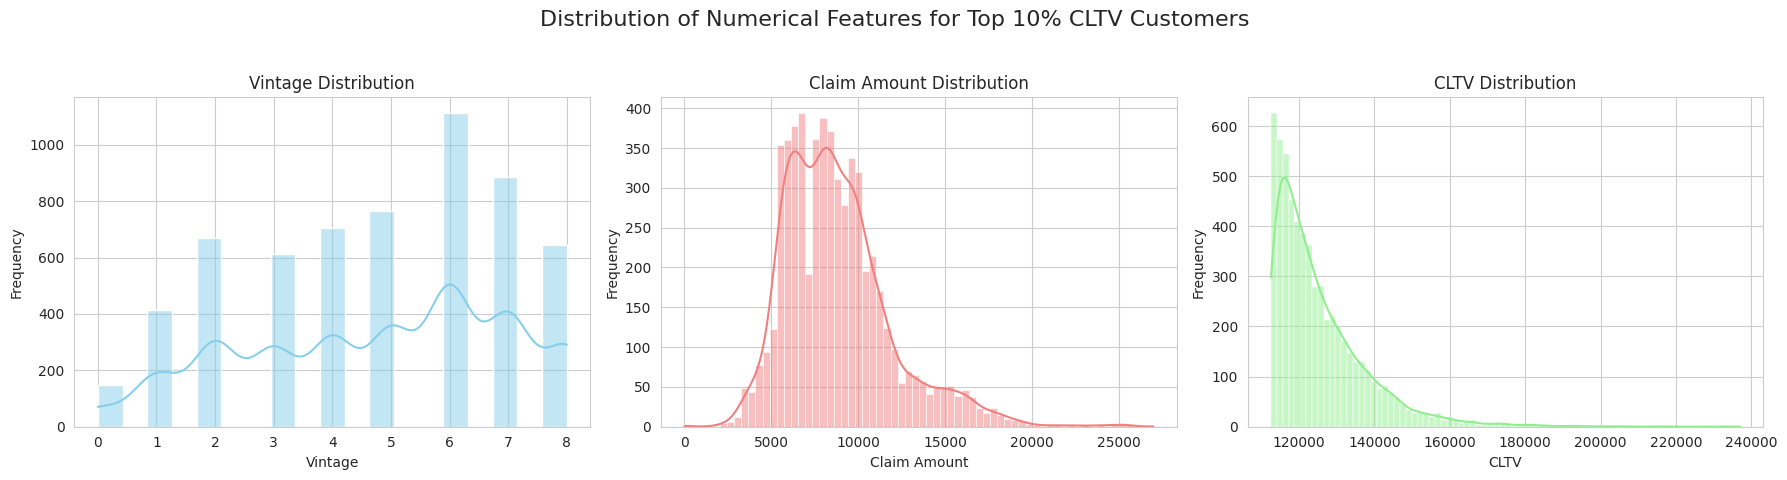

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
sns.set_style("whitegrid")

# Plotting numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Numerical Features for Top 10% CLTV Customers', fontsize=16)

sns.histplot(top_cltv_customers['vintage'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Vintage Distribution')
axes[0].set_xlabel('Vintage')
axes[0].set_ylabel('Frequency')

sns.histplot(top_cltv_customers['claim_amount'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Claim Amount Distribution')
axes[1].set_xlabel('Claim Amount')
axes[1].set_ylabel('Frequency')

sns.histplot(top_cltv_customers['cltv'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('CLTV Distribution')
axes[2].set_xlabel('CLTV')
axes[2].set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Task
Visualize the distributions of categorical features such as 'gender', 'area', 'qualification', 'marital_status', 'policy', and 'type_of_policy' for the top 10% CLTV customers using count plots, and then summarize these findings along with the descriptive statistics and numerical feature visualizations to create a comprehensive profile of high-potential customers, finally deriving actionable insights for personalized experience programs.

## Visualize Categorical Feature Distributions

### Subtask:
Create count plots for categorical features such as 'gender', 'area', 'qualification', 'marital_status', 'policy', and 'type_of_policy' for the top CLTV customers. This will provide visual insights into the demographic and policy preferences of these high-potential customers, helping to understand their distinct profiles.


**Reasoning**:
To visualize the distribution of categorical features for the top CLTV customers, I will create count plots for each specified categorical column. This will help in understanding the demographic and policy preferences of these high-potential customers.



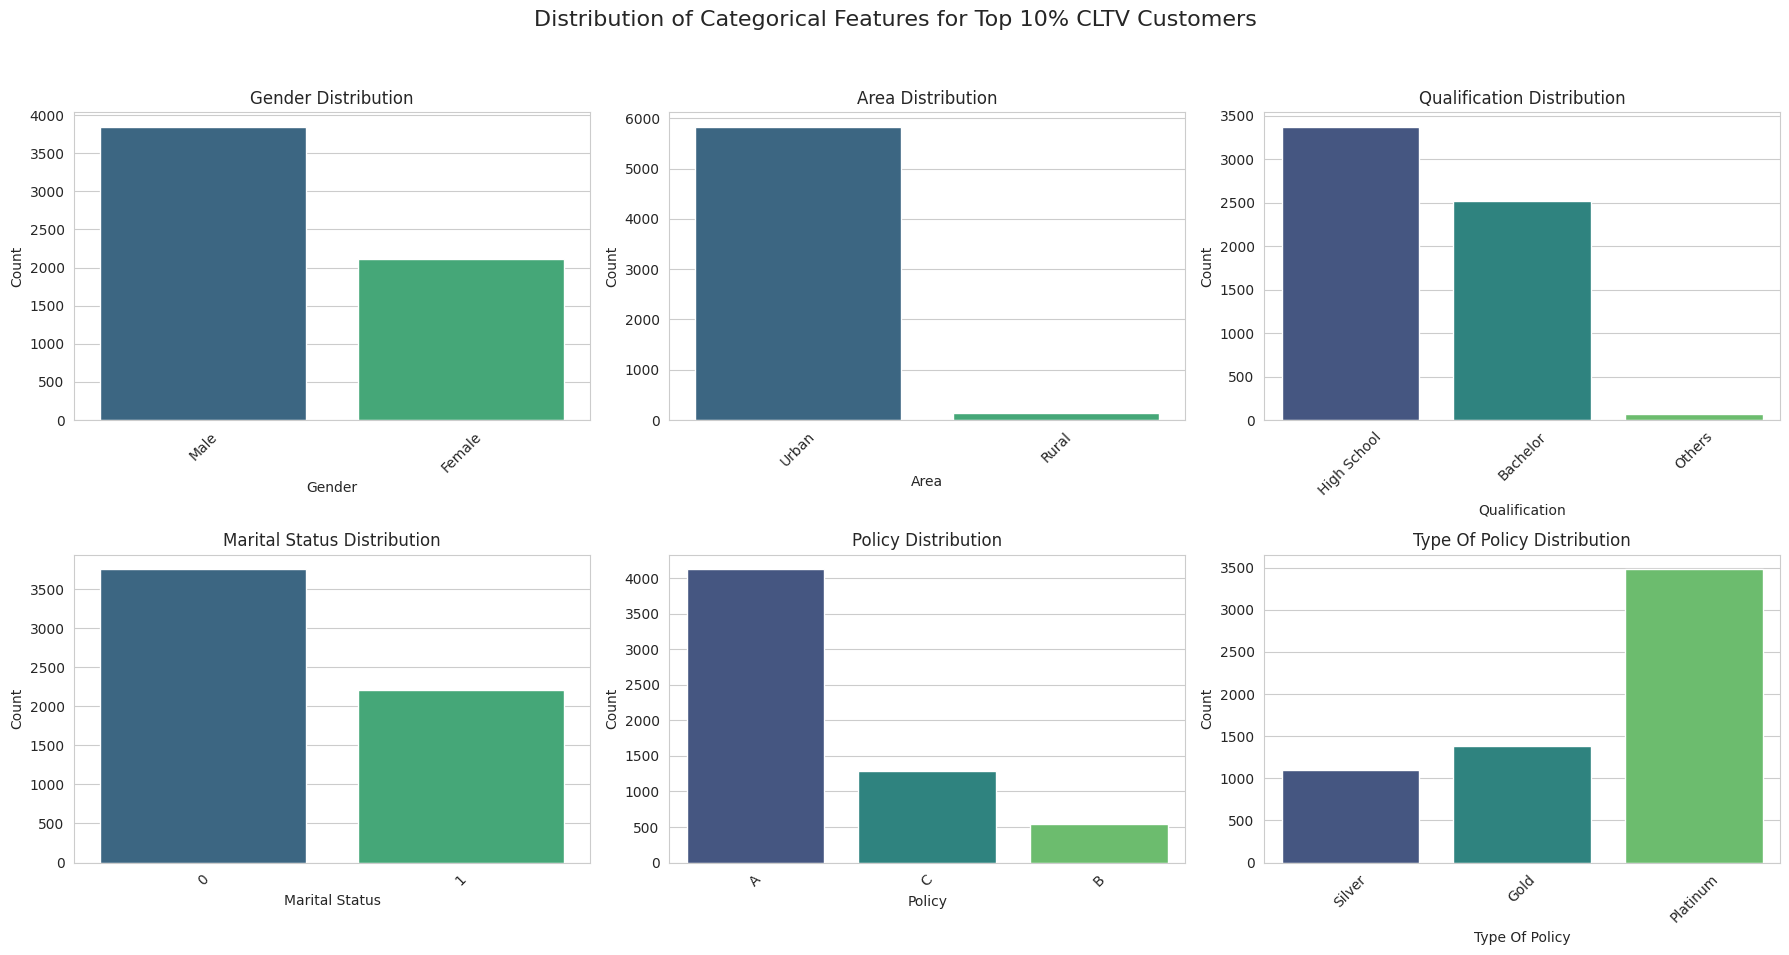

In [21]:
categorical_features = ['gender', 'area', 'qualification', 'marital_status', 'policy', 'type_of_policy']

# Calculate number of rows and columns for subplots
n_cols = 3
n_rows = (len(categorical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))
fig.suptitle('Distribution of Categorical Features for Top 10% CLTV Customers', fontsize=16)

# Flatten axes for easy iteration if n_rows > 1
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(data=top_cltv_customers, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Summary of Top CLTV Customer Characteristics and Actionable Insights

Based on the descriptive statistics and visualizations for the top 10% CLTV customers, we can identify several key characteristics and derive actionable insights for personalized experience programs:

### Numerical Features:
- **CLTV Distribution**: The CLTV values for the top 10% customers range from approximately 112,568 to 237,015, with a mean of about 125,462. The distribution is somewhat right-skewed, indicating a few customers with exceptionally high CLTV.
- **Vintage Distribution**: The 'vintage' (years as a customer) shows a relatively uniform distribution, with a slight peak around 5-7 years, suggesting that long-term customers tend to have higher CLTV, but new customers can also be high-potential.
- **Claim Amount Distribution**: 'Claim_amount' also shows a range, with a mean of around 8,821. The distribution is varied, but generally higher claim amounts are observed, which could be indicative of customers with comprehensive policies or frequent claims, contributing to their value.

### Categorical Features:
- **Gender**: A significant majority (around 64.5%) of the top CLTV customers are Male, compared to 35.5% Female. This suggests that marketing efforts for high-value segments might be more effective when tailored towards male customers.
- **Area**: An overwhelming majority (around 97.8%) of top CLTV customers reside in Urban areas. This indicates that urban customers are a primary target for high-potential CLTV, and efforts should be concentrated there, or strategies developed to increase CLTV in rural areas.
- **Qualification**: 'High School' (56.6%) and 'Bachelor' (42.2%) are the predominant qualifications among top CLTV customers. This demographic likely represents a stable income group capable of higher spending on insurance products.
- **Marital Status**: A large portion (around 63%) of top CLTV customers are unmarried (marital_status = 0). This could mean that single individuals or those without a spouse often invest more in personal insurance or have higher disposable income for comprehensive policies.
- **Policy Type**: 'Policy A' (69.3%) and 'Policy C' (21.6%) are significantly more prevalent. This suggests that these specific policy types are associated with higher customer lifetime value. 'Policy B' has a much smaller share (9.1%).
- **Type of Policy**: 'Platinum' (58.4%) and 'Gold' (23.1%) policies dominate among top CLTV customers, with 'Silver' having a smaller share (18.5%). This strongly indicates that customers opting for premium policy types are the most valuable.

### Actionable Insights for Personalized Experience Programs:
1.  **Targeted Marketing**: Focus marketing campaigns and product development towards urban males, particularly those with 'High School' or 'Bachelor' qualifications, as they represent the largest segment of high-potential customers.
2.  **Product Bundling & Upselling**: Actively promote 'Platinum' and 'Gold' policies, especially 'Policy A' and 'Policy C', to existing customers with lower-tier policies or new customers, highlighting their long-term value and benefits.
3.  **Customer Retention for Premium Policies**: Implement special loyalty programs and enhanced service for customers holding 'Platinum' and 'Gold' policies to ensure their continued satisfaction and retention, as they drive significant CLTV.
4.  **Tailored Communications for Marital Status**: Develop personalized communication strategies for unmarried customers, potentially offering products or services that align with their specific life stages and financial goals, given their high representation in the top CLTV segment.
5.  **Geographic Strategy**: While the focus should be on urban areas, explore specific initiatives or product adaptations for rural customers to potentially increase their CLTV contribution, though this might be a secondary focus.
6.  **Analyze High Claimers**: Investigate the characteristics of high 'claim_amount' customers. If these claims are due to comprehensive coverage and not excessive risk, these customers might be excellent candidates for further engagement and loyalty programs.

## Summary:

### Q&A
The primary goal was to create a comprehensive profile of high-potential customers (top 10% CLTV) by visualizing their categorical feature distributions and summarizing these findings alongside descriptive statistics and numerical feature visualizations, ultimately deriving actionable insights for personalized experience programs.

### Data Analysis Key Findings
*   **CLTV Distribution**: For the top 10% customers, CLTV values ranged from approximately 112,568 to 237,015, with a mean of about 125,462, showing a somewhat right-skewed distribution.
*   **Vintage Distribution**: The years as a customer ('vintage') showed a relatively uniform distribution, with a slight peak around 5-7 years.
*   **Claim Amount Distribution**: Claim amounts had a mean of around 8,821, indicating generally higher claim amounts among this segment.
*   **Gender**: A significant majority of top CLTV customers (approximately 64.5%) are male, while 35.5% are female.
*   **Area**: An overwhelming proportion (around 97.8%) of high CLTV customers reside in urban areas.
*   **Qualification**: The predominant qualifications among these customers are 'High School' (56.6%) and 'Bachelor' (42.2%).
*   **Marital Status**: A large portion (around 63%) of top CLTV customers are unmarried.
*   **Policy Type**: 'Policy A' (69.3%) and 'Policy C' (21.6%) are significantly more prevalent among high-value customers.
*   **Type of Policy**: 'Platinum' (58.4%) and 'Gold' (23.1%) policies dominate the top CLTV customer segment.

### Insights or Next Steps
*   Focus marketing campaigns and product development towards urban males with 'High School' or 'Bachelor' qualifications, as they represent the largest segment of high-potential customers.
*   Actively promote 'Platinum' and 'Gold' policies, especially 'Policy A' and 'Policy C', to existing customers with lower-tier policies or new customers, highlighting their long-term value and benefits.


# Task
Load "submission.csv" into a DataFrame and display its first five rows.

## Load Submission File

### Subtask:
Load the 'submission.csv' file into a pandas DataFrame.


**Reasoning**:
Load the 'submission.csv' file into a pandas DataFrame named `submission_df` and display its head to verify successful loading.



In [22]:
import pandas as pd

submission_df = pd.read_csv('submission.csv')
print("Submission file loaded successfully.")
submission_df.head()

Submission file loaded successfully.


,id,cltv
0,89393,78576.154576
1,89394,107792.733820
2,89395,81157.949563
3,89396,79187.545719
4,89397,88552.687770


## Summary:

### Data Analysis Key Findings
*   The `submission.csv` file was successfully loaded into a pandas DataFrame named `submission_df`.
*   The loaded DataFrame contains columns 'id' and 'cltv'.
*   The first five rows of the `submission_df` were displayed, confirming the data was loaded correctly.

### Insights or Next Steps
*   The `submission_df` is now available and ready for further data manipulation, analysis, or submission based on the project requirements.
